In [54]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import make_scorer, precision_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.decomposition import PCA
from sklearn import model_selection
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import scipy as sp
import folium


In [55]:
tree_data = pd.read_csv(r'..\Data\new_york_tree_census_2015.csv')

In [56]:
tree_data_small = tree_data[['tree_dbh', 'curb_loc', 'health', 'spc_common', 'sidewalk', 'zipcode']].copy()
tree_data_small

,tree_dbh,curb_loc,health,spc_common,sidewalk,zipcode
0,10,OnCurb,Good,green ash,NoDamage,11366
1,9,OnCurb,Good,honeylocust,NoDamage,11370
2,7,OnCurb,Good,Callery pear,NoDamage,11434
3,10,OnCurb,Good,Callery pear,NoDamage,11209
4,4,OnCurb,Good,'Schubert' chokecherry,NoDamage,11692
...,...,...,...,...,...,...
683783,2,OnCurb,Poor,purple-leaf plum,NoDamage,11231
683784,2,OnCurb,NaN,NaN,NaN,11001
683785,2,OnCurb,NaN,NaN,NaN,11230
683786,18,OnCurb,Good,northern red oak,Damage,11420


In [57]:
# initial clean of the data - drop na
print("tree dataset rows total: ", len(tree_data_small))
tree_data_small.dropna(inplace=True)
print("tree dataset rows after na drop: ", len(tree_data_small))

tree_data_small.info()

tree dataset rows total:  683788
tree dataset rows after na drop:  652166
<class 'pandas.core.frame.DataFrame'>
Index: 652166 entries, 0 to 683787
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   tree_dbh    652166 non-null  int64 
 1   curb_loc    652166 non-null  object
 2   health      652166 non-null  object
 3   spc_common  652166 non-null  object
 4   sidewalk    652166 non-null  object
 5   zipcode     652166 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 34.8+ MB


In [58]:
def get_ratio(series):
       val_counts = series.value_counts()
       if len(val_counts) > 1:
              return val_counts.iloc[0]/ val_counts.iloc[1]
       # if there is only one value then the ratio is 1
       return 1
           
def get_first(series):
       val_counts = series.value_counts()
       return val_counts.index[0]

def get_second(series):
       val_counts = series.value_counts()
       if len(val_counts) > 1:
              return val_counts.index[1]
       else:
              return val_counts.index[-1]

def get_third(series):
       val_counts = series.value_counts()
       if len(val_counts) > 2:
              return val_counts.index[2]
       else:
              return val_counts.index[-1]
       
def count_unique_vals(series):
       return series.value_counts().to_dict()
    
       

In [59]:
# because we are going to join on zip code, we need to make meaningful aggregates for each column per zip code
tree_data_agg = tree_data_small.groupby('zipcode').agg(
       dbh_mean=('tree_dbh', 'mean'),
       curb_ratio=('curb_loc', get_ratio),
       sidewalk_ratio=('sidewalk', get_ratio),
       health_counts=('health', count_unique_vals),
       species_1=('spc_common', get_first),
       species_2=('spc_common', get_second),
       species_3=('spc_common', get_third),
       tree_count=('tree_dbh', 'size')
    
).reset_index()

health_counts_df = pd.DataFrame(tree_data_agg['health_counts'].tolist()).fillna(0).astype(int)
tree_data_agg = pd.concat([tree_data_agg, health_counts_df], axis=1).drop(columns=['health_counts'])

tree_data_agg


,zipcode,dbh_mean,curb_ratio,sidewalk_ratio,species_1,species_2,species_3,tree_count,Good,Fair,Poor
0,83,16.505365,1.273171,3.217195,American elm,pin oak,ginkgo,932,885,39,8
1,10001,7.365882,46.222222,4.629139,honeylocust,Callery pear,Japanese zelkova,850,719,100,31
2,10002,8.459222,5.255072,4.678947,London planetree,honeylocust,ginkgo,2158,1656,387,115
3,10003,9.077200,91.523810,2.672968,honeylocust,Callery pear,ginkgo,1943,1480,361,102
4,10004,6.658120,3.178571,28.250000,honeylocust,ginkgo,Japanese zelkova,117,97,17,3
...,...,...,...,...,...,...,...,...,...,...,...
186,11691,8.813316,27.221053,4.432624,honeylocust,London planetree,cherry,5362,3761,1258,343
187,11692,4.962963,12.027972,5.900000,Callery pear,cherry,Sophora,1863,1122,523,218
188,11693,7.897335,6.914062,12.876712,London planetree,honeylocust,Callery pear,1013,518,288,207
189,11694,8.053841,17.358382,6.234624,honeylocust,Callery pear,cherry,3176,1958,833,385


In [60]:
# need to encode categorical data
encoder = LabelEncoder()

# encode the three species columns
tree_encoded_df = tree_data_agg.copy()
for col in ['species_1', 'species_2', 'species_3']:
    tree_encoded_df[col] = encoder.fit_transform(tree_data_agg[col])

tree_encoded_df

,zipcode,dbh_mean,curb_ratio,sidewalk_ratio,species_1,species_2,species_3,tree_count,Good,Fair,Poor
0,83,16.505365,1.273171,3.217195,0,13,10,932,885,39,8
1,10001,7.365882,46.222222,4.629139,7,2,3,850,719,100,31
2,10002,8.459222,5.255072,4.678947,3,10,10,2158,1656,387,115
3,10003,9.077200,91.523810,2.672968,7,2,10,1943,1480,361,102
4,10004,6.658120,3.178571,28.250000,7,8,3,117,97,17,3
...,...,...,...,...,...,...,...,...,...,...,...
186,11691,8.813316,27.221053,4.432624,7,4,9,5362,3761,1258,343
187,11692,4.962963,12.027972,5.900000,1,7,8,1863,1122,523,218
188,11693,7.897335,6.914062,12.876712,3,10,2,1013,518,288,207
189,11694,8.053841,17.358382,6.234624,7,2,9,3176,1958,833,385


In [61]:
crime_data = pd.read_csv(r'..\Data\2015_Crime.csv', low_memory=False)

In [62]:
crime_data.head()
# Keep only the specified columns
crime_data = crime_data[['Violation Date', 'Violation Time', 'Issuing Agency',
                         'Violation Location (Zip Code)', 
                         'Penalty Imposed', 'Charge #1: Code', 
                         'Charge #2: Code', 'Charge #3: Code', 'Charge #4: Code', 
                         'Charge #5: Code', 'Charge #6: Code', 'Charge #7: Code', 
                         'Charge #8: Code', 'Charge #9: Code', 'Charge #10: Code']]

# Remove rows where the 'Violation Location (Zip Code)' column is NaN
# print("crime dataset rows total: ", len(crime_data))
# crime_data = crime_data.dropna(subset=['Violation Location (Zip Code)'])
# 
# crime_data = crime_data.dropna(subset=['Issuing Agency'])
# print("crime dataset rows after na drop: ", len(crime_data))

crime_data.head()

,Violation Date,Violation Time,Issuing Agency,Violation Location (Zip Code),Penalty Imposed,Charge #1: Code,Charge #2: Code,Charge #3: Code,Charge #4: Code,Charge #5: Code,Charge #6: Code,Charge #7: Code,Charge #8: Code,Charge #9: Code,Charge #10: Code
0,06/30/2015,07:50:00,SANITATION OTHERS,10016,300.0,AS18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,06/30/2015,NaN,DOHMH - BFSCS,11238,800.0,04A,05D,05D,10A,04A,05D,05D,10A,NaN,NaN
2,06/30/2015,13:54:00,DEPT OF TRAN,NaN,830.0,AD4F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,06/30/2015,14:10:00,DEPT OF TRAN,NaN,830.0,AD4F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,06/30/2015,14:04:00,DEPT OF TRANSPORTATION,NaN,780.0,AD09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
# Extract columns containing charges
charge_columns = [col for col in crime_data.columns if "Charge" in col]
print("crime data len pre drop pre melt: ", len(crime_data))

crime_data = crime_data.melt(
    id_vars=[col for col in crime_data.columns if col not in charge_columns],  # Keep these columns unchanged  # Columns to unpivot
    var_name="Original Charge Column",  # New column for original charge column names
    value_name="Charge: Code",  # New column for charge values
)

# Drop rows where Charge: Code is NaN
# crime_data = crime_data.dropna(subset=["Charge: Code"]).drop(columns=["Original Charge Column"])
print("crime data len pre drop: ", len(crime_data))
crime_data.dropna(inplace=True)
print("crime data len post drop: ", len(crime_data))

# Reset index for a clean DataFrame
crime_data = crime_data.reset_index(drop=True)

# because we are going to join on zip code, we need to make meaningful aggregates for each column per zip code
crime_data_final = crime_data.groupby('Violation Location (Zip Code)').agg(
    issuing_agency_1=('Issuing Agency', get_first),
    issuing_agency_2=('Issuing Agency', get_second),
    issuing_agency_3=('Issuing Agency', get_third),
    penalty_imposed=('Penalty Imposed', 'mean'),
    charge_1 = ('Charge: Code', get_first),
    charge_2 = ('Charge: Code', get_second),
    charge_3 = ('Charge: Code', get_third),
    crime_count = ('Issuing Agency', 'size')
).reset_index()

# calculating if the crime count is above the mean
crime_data_final['crime_above_avg'] = (crime_data_final['crime_count'] > crime_data_final['crime_count'].mean()).astype(int)

crime_data_final.rename(columns={'Violation Location (Zip Code)': 'zipcode'}, inplace=True)

crime_data_final.drop(crime_data_final[~crime_data_final['zipcode'].astype(str).apply(lambda x: x.isdigit())].index, inplace=True)

crime_data_final['zipcode'] = crime_data_final['zipcode'].astype(int)

crime_data_final.head()

crime data len pre drop pre melt:  750352
crime data len pre drop:  7503520
crime data len post drop:  414769


,zipcode,issuing_agency_1,issuing_agency_2,issuing_agency_3,penalty_imposed,charge_1,charge_2,charge_3,crime_count,crime_above_avg
0,0,PCS - DOHMH,DOS - ENFORCEMENT AGENTS,SANITATION DEPT,372.619048,AH3P,AS30,AS06,21,0
1,83,PARKS AND RECR,PARKS AND RECR,PARKS AND RECR,35.000000,AA35,AA21,AA75,5,0
2,7620,SANITATION OTHERS,SANITATION OTHERS,SANITATION OTHERS,0.000000,AS6M,AS6M,AS6M,1,0
3,10000,PARKS DEPARTMENT,PARKS AND RECR,DEPT OF HEALTH,269.525692,AA28,AA74,AA02,253,0
4,10001,FIRE DEPARTMENT OF NYC,DEPT. OF BUILDINGS,SANITATION DEPT,1099.064794,BF35,AS18,AS07,3133,1


In [64]:
encoder = LabelEncoder()

# encode the three species columns
crime_encoded_df = crime_data_final.copy()
for col in ['issuing_agency_1', 'issuing_agency_2', 'issuing_agency_3']:
    crime_encoded_df[col] = encoder.fit_transform(crime_data_final[col])

for col in ['charge_1', 'charge_2', 'charge_3']:
    crime_encoded_df[col] = encoder.fit_transform(crime_data_final[col])


In [65]:
crime_encoded_df

,zipcode,issuing_agency_1,issuing_agency_2,issuing_agency_3,penalty_imposed,charge_1,charge_2,charge_3,crime_count,crime_above_avg
0,0,9,8,12,372.619048,9,28,21,21,0
1,83,7,12,9,35.000000,2,1,2,5,0
2,7620,14,18,14,0.000000,24,29,29,1,0
3,10000,8,12,3,269.525692,1,2,0,253,0
4,10001,6,6,12,1099.064794,41,24,22,3133,1
...,...,...,...,...,...,...,...,...,...,...
230,11694,12,4,7,817.061224,21,24,4,490,0
231,11697,3,4,8,3750.952381,28,40,37,21,0
232,14330,6,9,8,2000.000000,40,46,43,2,0
233,2209,6,9,8,1000.000000,32,45,42,1,0


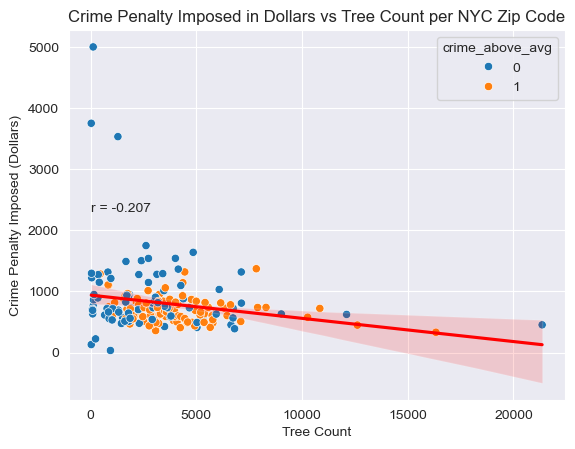

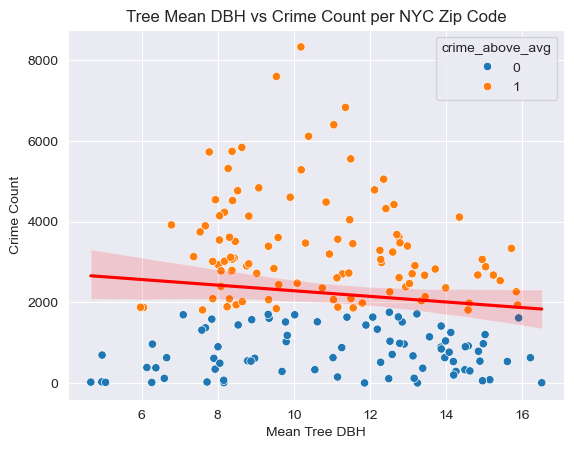

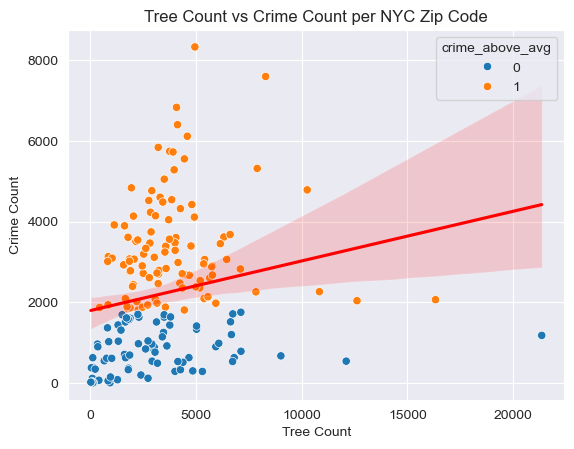

In [66]:
# combining datasets for ML algs
tree_final = tree_encoded_df
crime_final = crime_encoded_df

merged_df = pd.merge(tree_final, crime_final, on='zipcode', how='inner')

# visualize data
sns.scatterplot(x='tree_count', y='penalty_imposed', hue='crime_above_avg', data=merged_df)
sns.regplot(x='tree_count', y='penalty_imposed', scatter=False, color='red', data=merged_df)
r, p = sp.stats.pearsonr(merged_df['tree_count'], merged_df['penalty_imposed'])
plt.ylabel('Crime Penalty Imposed (Dollars)')
plt.xlabel('Tree Count')
plt.title('Crime Penalty Imposed in Dollars vs Tree Count per NYC Zip Code')
plt.annotate("r = {:.3f}".format(r), (1, 2300))
plt.show()

sns.scatterplot(x='dbh_mean', y='crime_count', hue='crime_above_avg', data=merged_df)
sns.regplot(x='dbh_mean', y='crime_count', scatter=False, color='red', data=merged_df)
r, p = sp.stats.pearsonr(merged_df['dbh_mean'], merged_df['crime_count'])
plt.ylabel('Crime Count')
plt.xlabel('Mean Tree DBH')
plt.title('Tree Mean DBH vs Crime Count per NYC Zip Code')
plt.annotate("r = {:.3f}".format(r), (5, 13000))
plt.show()

sns.scatterplot(x='tree_count', y='crime_count', hue='crime_above_avg', data=merged_df)
sns.regplot(x='tree_count', y='crime_count', scatter=False, color='red', data=merged_df)
r, p = sp.stats.pearsonr(merged_df['tree_count'], merged_df['crime_count'])
plt.ylabel('Crime Count')
plt.xlabel('Tree Count')
plt.title('Tree Count vs Crime Count per NYC Zip Code')
plt.annotate("r = {:.3f}".format(r), (0, 13000))
plt.show()


In [67]:
to_scale_df = merged_df

# scaled data
non_scaling_cols = ['zipcode', 'crime_above_avg']
scaling_cols = [col for col in to_scale_df.columns if col not in non_scaling_cols]
scaler = StandardScaler()
to_scale_df[scaling_cols] = pd.DataFrame(scaler.fit_transform(to_scale_df[scaling_cols]))
scaled_df = to_scale_df[scaling_cols + non_scaling_cols]

scaled_df


,dbh_mean,curb_ratio,sidewalk_ratio,species_1,species_2,species_3,tree_count,Good,Fair,Poor,issuing_agency_1,issuing_agency_2,issuing_agency_3,penalty_imposed,charge_1,charge_2,charge_3,crime_count,zipcode,crime_above_avg
0,2.006330,-0.801084,-0.089322,-2.084195,1.347967,0.413509,-0.918989,-0.851318,-1.116388,-1.078388,-0.880063,0.211513,-0.081211,-1.504463,-2.653042,-2.792876,-2.657081,-1.345983,83,0
1,-1.244936,0.271659,0.003921,0.790404,-1.361209,-1.107362,-0.948270,-0.923498,-0.974414,-0.896107,-1.163758,-1.064423,0.674055,0.569492,2.952890,-0.221218,-0.309256,0.549046,10001,1
2,-0.855993,-0.706053,0.007210,-0.852224,0.609101,0.413509,-0.481202,-0.516069,-0.306435,-0.230386,1.105799,1.062136,-1.088233,0.004692,-0.353172,-0.221218,0.277700,0.778654,10002,1
3,-0.636154,1.352815,-0.125262,0.790404,-1.361209,0.413509,-0.557975,-0.592598,-0.366949,-0.333414,0.538409,-0.639111,-0.332967,-0.281346,-0.065688,-0.444840,-1.248386,1.583193,10003,1
4,-1.496714,-0.755610,1.563816,0.790404,0.116524,-1.107362,-1.210014,-1.193958,-1.167592,-1.118014,-1.163758,0.636824,-1.591743,-0.082173,-2.796783,2.909497,-1.600560,-0.969158,10004,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,-0.730028,-0.181818,-0.009057,0.790404,-0.868631,0.196241,0.662901,0.399233,1.720775,1.576571,-1.447452,1.487448,0.674055,-0.607682,0.509279,-0.444840,-0.074474,0.441209,11691,1
182,-2.099747,-0.544413,0.087847,-1.673538,-0.129765,-0.021026,-0.586542,-0.748265,0.010098,0.585915,1.105799,-0.639111,0.674055,-0.479432,0.509279,0.002405,-0.074474,-0.929779,11692,0
183,-1.055878,-0.666460,0.548581,-0.852224,0.609101,-1.324629,-0.890065,-1.010898,-0.536853,0.498737,1.105799,-0.639111,0.674055,-0.531674,0.509279,-0.444840,-0.778821,-0.978851,11693,0
184,-1.000202,-0.417198,0.109945,0.790404,-1.361209,0.196241,-0.117689,-0.384753,0.731608,1.909432,0.538409,-1.489734,-0.584722,0.019843,0.078053,-0.221218,-2.422298,-1.052156,11694,0


- Testing Different Values of k -
Best k: 4


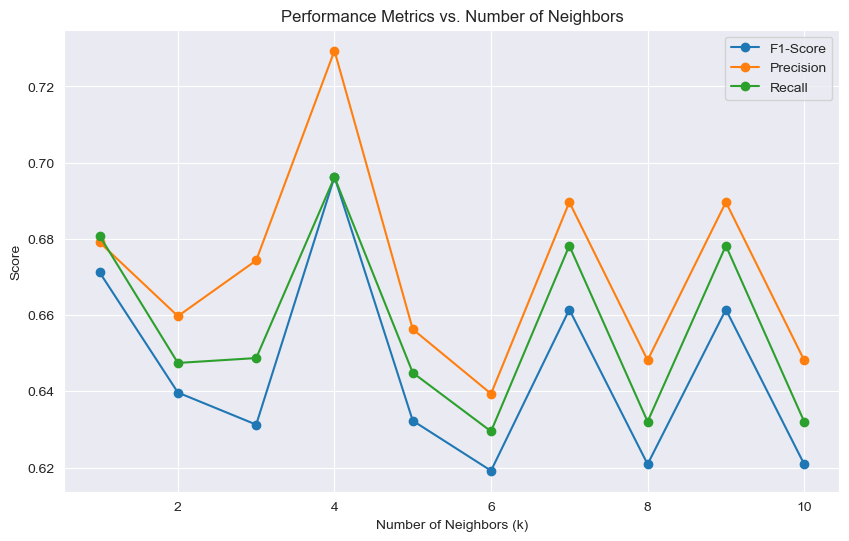

- 5-Fold Cross Validation -
F1:  0.6963
Precision:  0.7293
Recall:  0.6962


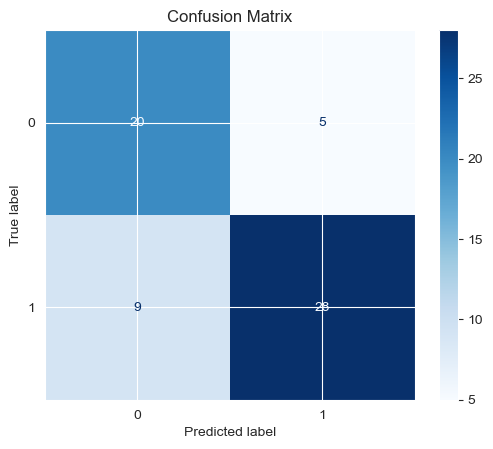

In [68]:
# ML algs - predicting crime count 

# train test split
X = scaled_df.drop('crime_above_avg', axis=1)
y = scaled_df['crime_above_avg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3.) 

# Finding the optimal k 
print("- Testing Different Values of k -") 
k_range = range(1, 11)  # Test k from 1 to 10

results = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k) 
    knn.fit(X_train, y_train)
    precision_scorer = make_scorer(precision_score, average='weighted', zero_division=0) 
    scores = model_selection.cross_validate(knn, X_test, y_test, cv=5,
                                             scoring={'precision_weighted': precision_scorer,
                                                      'f1_weighted': 'f1_weighted',
                                                      'recall_weighted': 'recall_weighted'})

    results.append({
        'k': k,
        'f1_weighted': np.mean(scores['test_f1_weighted']), 
        'precision_weighted': np.mean(scores['test_precision_weighted']), 
        'recall_weighted': np.mean(scores['test_recall_weighted'])
    })

# Convert results to DataFrame 
results_df = pd.DataFrame(results) 

# Find the best k 
best_k = results_df.loc[results_df['f1_weighted'].idxmax(), 'k'] 
print(f"Best k: {best_k}") 

# Visualize performance metrics vs. k 
plt.figure(figsize=(10, 6))
plt.plot(results_df['k'], results_df['f1_weighted'], label='F1-Score', marker='o')
plt.plot(results_df['k'], results_df['precision_weighted'], label='Precision', marker='o')
plt.plot(results_df['k'], results_df['recall_weighted'], label='Recall', marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Score')
plt.title('Performance Metrics vs. Number of Neighbors')
plt.legend()
plt.grid(True)
plt.show()

# Train the model using the best k 
knn = KNeighborsClassifier(n_neighbors=best_k) 
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test) 

print("- 5-Fold Cross Validation -") 

precision_scorer = make_scorer(precision_score, average='weighted', zero_division=0) 

scores = model_selection.cross_validate(knn, X_test, y_test, cv=5,
                                        scoring={'precision_weighted': precision_scorer,  
                                                 'f1_weighted': 'f1_weighted',  
                                                 'recall_weighted': 'recall_weighted'}) 

print("F1: ", f"{np.mean(scores['test_f1_weighted']):.4f}") 
print("Precision: ", f"{np.mean(scores['test_precision_weighted']):.4f}") 
print("Recall: ", f"{np.mean(scores['test_recall_weighted']):.4f}") 



# Compute confusion matrix 
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_) 

# Display confusion matrix 

disp = ConfusionMatrixDisplay(confusion_matrix=cm) 
disp.plot(cmap='Blues') 
plt.title("Confusion Matrix") 
plt.show() 

C:\Users\scint\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\scint\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\scint\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\scint\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

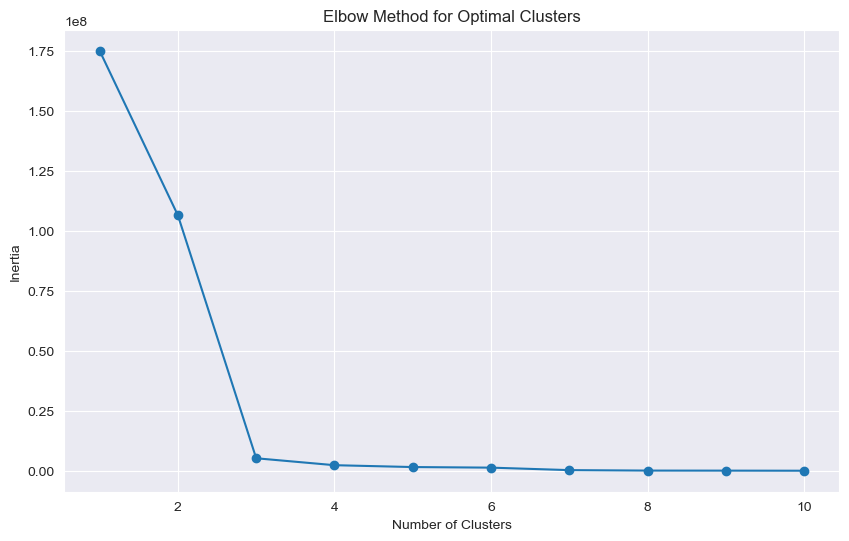

C:\Users\scint\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\scint\AppData\Local\Temp\ipykernel_14748\3762218416.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scaled_df['cluster'] = kmeans.fit_predict(scaled_df)


              zipcode  dbh_mean  curb_ratio  sidewalk_ratio  species_1  \
cluster                                                                  
0        10208.963855 -0.644268   -0.205014        0.121034   0.340166   
1        11309.382353  0.504587    0.174679       -0.097612  -0.256368   
2           83.000000  2.006330   -0.801084       -0.089322  -2.084195   

         species_2  species_3  tree_count      Good      Fair      Poor  \
cluster                                                                   
0        -0.275164  -0.044585   -0.204185 -0.210729 -0.174191 -0.097758   
1         0.210693   0.032226    0.175160  0.179822  0.152689  0.090120   
2         1.347967   0.413509   -0.918989 -0.851318 -1.116388 -1.078388   

         issuing_agency_1  issuing_agency_2  issuing_agency_3  \
cluster                                                         
0               -0.175954          0.060348         -0.005381   
1                0.151806         -0.051180          0.005

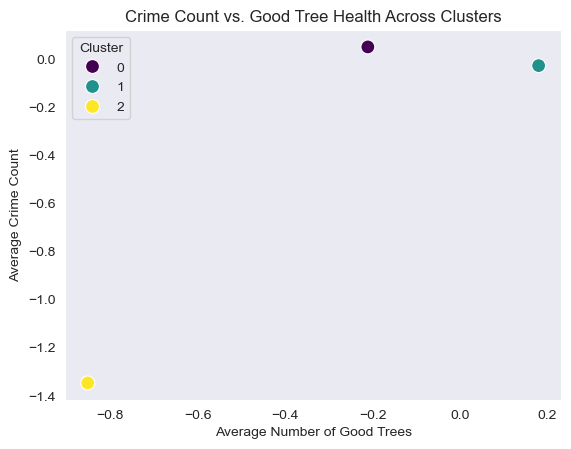

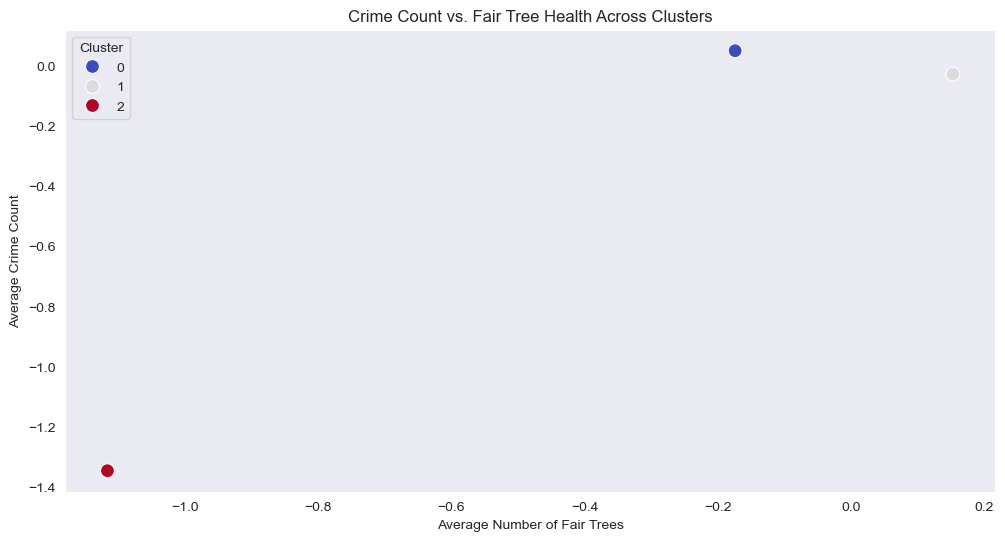

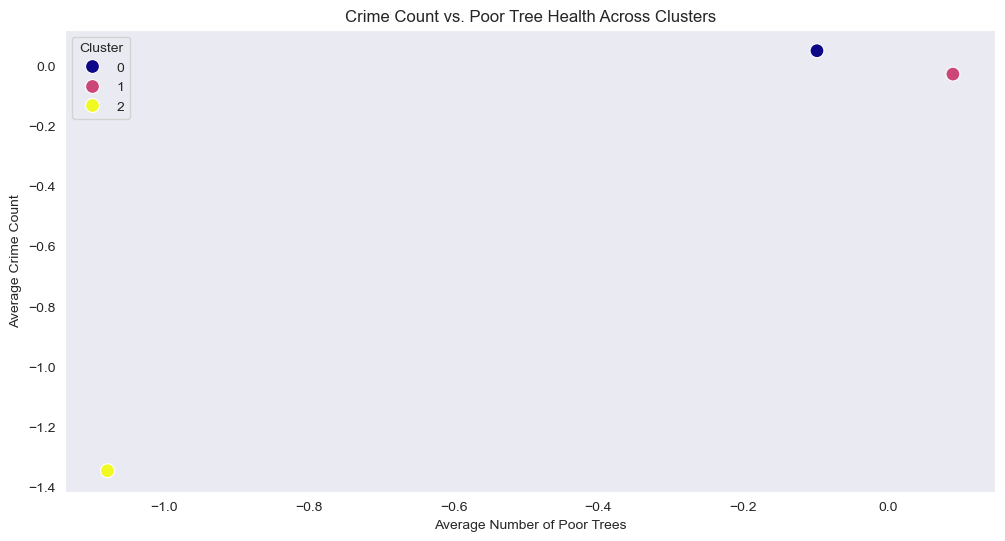

In [69]:
# k means
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

optimal_clusters = 3  

kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
scaled_df['cluster'] = kmeans.fit_predict(scaled_df)

merged_df['cluster'] = scaled_df['cluster']

print(merged_df.groupby('cluster').mean()) 
merged_df.to_csv('kmeans_clustered_data.csv', index=False)

sns.scatterplot(
    x=merged_df.groupby('cluster')['Good'].mean(),
    y=merged_df.groupby('cluster')['crime_count'].mean(),
    hue=merged_df.groupby('cluster').size().index, 
    palette='viridis',
    s=100,
    legend='full'
)
plt.title('Crime Count vs. Good Tree Health Across Clusters')
plt.xlabel('Average Number of Good Trees')
plt.ylabel('Average Crime Count')
plt.legend(title='Cluster')
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(
    x=merged_df.groupby('cluster')['Fair'].mean(),
    y=merged_df.groupby('cluster')['crime_count'].mean(),
    hue=merged_df.groupby('cluster').size().index,  
    palette='coolwarm',
    s=100,
    legend='full'
)
plt.title('Crime Count vs. Fair Tree Health Across Clusters')
plt.xlabel('Average Number of Fair Trees')
plt.ylabel('Average Crime Count')
plt.legend(title='Cluster')
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(
    x=merged_df.groupby('cluster')['Poor'].mean(),
    y=merged_df.groupby('cluster')['crime_count'].mean(),
    hue=merged_df.groupby('cluster').size().index,  
    palette='plasma',
    s=100,
    legend='full'
)
plt.title('Crime Count vs. Poor Tree Health Across Clusters')
plt.xlabel('Average Number of Poor Trees')
plt.ylabel('Average Crime Count')
plt.legend(title='Cluster')
plt.grid()
plt.show()

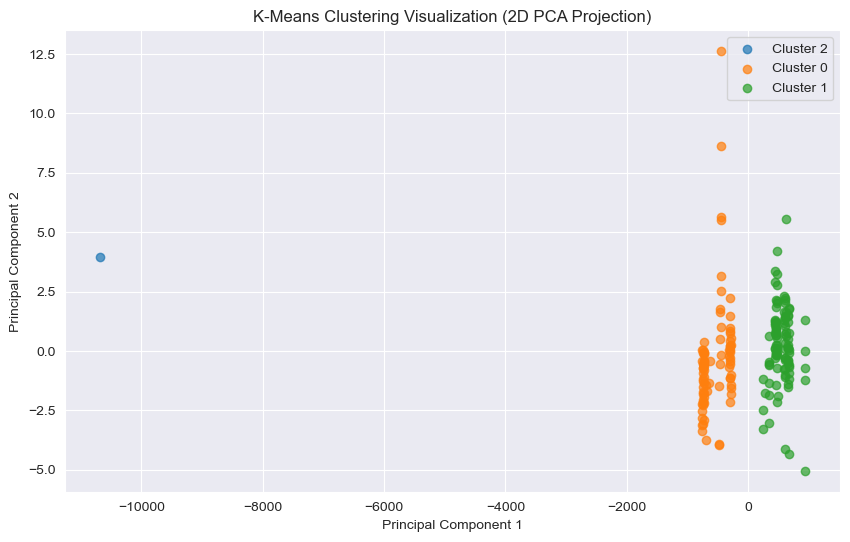

In [70]:
# pca
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df.drop(columns=['cluster']))

plt.figure(figsize=(10, 6))
for cluster in scaled_df['cluster'].unique():
    cluster_points = pca_components[scaled_df['cluster'] == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}', alpha=0.7)
    
plt.title('K-Means Clustering Visualization (2D PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

for col in merged_df.columns:
    if merged_df[col].dtype == 'datetime64[ns]' or isinstance(merged_df[col].iloc[0], pd.Timestamp):
        merged_df[col] = merged_df[col].astype(str)  
    elif merged_df[col].dtype == 'object':
        merged_df[col] = merged_df[col].astype(str)  

In [71]:
# map analysis
geojson_path = 'nyc-zip-code-tabulation-areas-polygons.geojson'  
geo_data = gpd.read_file(geojson_path)

geo_data = geo_data.explode(index_parts=False)
geo_data['postalCode'] = geo_data['postalCode'].astype(str)

merged_df['zipcode'] = merged_df['zipcode'].astype(str)

merged_geo = geo_data.set_index('postalCode').join(merged_df.set_index('zipcode'))

centroid = geo_data.geometry.centroid.unary_union.centroid
map_center = [centroid.y, centroid.x] 

crime_map = folium.Map(location=map_center, zoom_start=10)  
folium.Choropleth(
    geo_data=merged_geo.__geo_interface__,
    data=merged_df,
    columns=['zipcode', 'crime_count'],
    key_on='feature.id',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Crime Count'
).add_to(crime_map)
crime_map.save('crime_count_heatmap.html')  

tree_map = folium.Map(location=map_center, zoom_start=10) 
folium.Choropleth(
    geo_data=merged_geo.__geo_interface__,
    data=merged_df,
    columns=['zipcode', 'dbh_mean'],
    key_on='feature.id',
    fill_color='BuGn',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Average Tree Diameter (dbh_mean)'
).add_to(tree_map)
tree_map.save('dbh_mean_heatmap.html') 

C:\Users\scint\AppData\Local\Temp\ipykernel_14748\1683593165.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = geo_data.geometry.centroid.unary_union.centroid
